<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/Algorithms/MNIST_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root= 'data', train= True, download= True, transform= transform)
test_data = datasets.MNIST(root= 'data', train= False, download= True, transform= transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.19MB/s]


In [5]:
train_loader= DataLoader(train_data, batch_size= 10, shuffle= True)
test_loader= DataLoader(test_data, batch_size= 10, shuffle= False)

In [6]:
from typing import Self
class Model(nn.Module):

  def __init__(self, in_feat= 784, h1= 256, h2= 128, out_feat= 10):
    super().__init__()
    self.fc1 = nn.Linear(in_feat, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.fc3 = nn.Linear(h2, out_feat)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


In [9]:
torch.manual_seed(42)
model = Model().to(device)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

In [24]:
epochs= 5
losses= []
for epoch in range(epochs):
  running_loss= 0.0
  model.train()
  for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
  epoch_loss = running_loss / len(train_loader)
  losses.append(epoch_loss)
  print(f"Epoch: {epoch}, Loss:{losses}")



Epoch: 0, Loss:[0.01819866693645724]
Epoch: 1, Loss:[0.01819866693645724, 0.016899630526464173]
Epoch: 2, Loss:[0.01819866693645724, 0.016899630526464173, 0.0169877846462881]
Epoch: 3, Loss:[0.01819866693645724, 0.016899630526464173, 0.0169877846462881, 0.018452186034311112]
Epoch: 4, Loss:[0.01819866693645724, 0.016899630526464173, 0.0169877846462881, 0.018452186034311112, 0.01607562575319695]


Text(0.5, 1.0, 'Training loss')

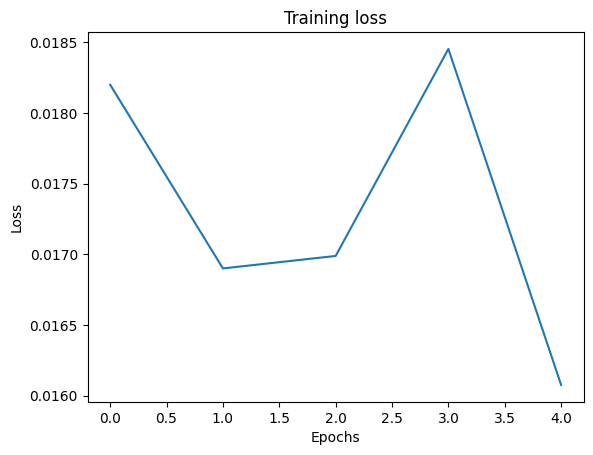

In [28]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training loss")

In [46]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)

        #
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        loss = criterion(outputs, labels)
        overall_loss += loss.item()
        print(f"Predicted class:{predicted}, Actual class: {labels}")

overall_loss = overall_loss/len(test_loader)

print(f"Overall Loss: {overall_loss:.4f}")

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Predicted class:tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], device='cuda:0'), Actual class: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], device='cuda:0')
Predicted class:tensor([0, 6, 9, 0, 1, 5, 9, 7, 3, 4], device='cuda:0'), Actual class: tensor([0, 6, 9, 0, 1, 5, 9, 7, 3, 4], device='cuda:0')
Predicted class:tensor([9, 6, 6, 5, 4, 0, 7, 4, 0, 1], device='cuda:0'), Actual class: tensor([9, 6, 6, 5, 4, 0, 7, 4, 0, 1], device='cuda:0')
Predicted class:tensor([3, 1, 3, 4, 7, 2, 7, 1, 2, 1], device='cuda:0'), Actual class: tensor([3, 1, 3, 4, 7, 2, 7, 1, 2, 1], device='cuda:0')
Predicted class:tensor([1, 7, 4, 2, 3, 5, 1, 2, 4, 4], device='cuda:0'), Actual class: tensor([1, 7, 4, 2, 3, 5, 1, 2, 4, 4], device='cuda:0')
Predicted class:tensor([6, 3, 5, 5, 6, 0, 4, 1, 9, 5], device='cuda:0'), Actual class: tensor([6, 3, 5, 5, 6, 0, 4, 1, 9, 5], device='cuda:0')
Predicted class:tensor([7, 8, 9, 3, 7, 4, 6, 4, 3, 0], device='cuda:0'), Actual class: tensor([7, 8, 9, 3, 7, 4, 6, 4, 3, 0], device='cuda:0')